In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, json

DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'

Mounted at /content/drive


In [ ]:
baseline_ablation = [
    {"model": "Logistic Regression (TF-IDF)", "train_fraction": 0.25, "train_samples": 29000,
     "accuracy": 0.932828, "macro_f1": 0.939816, "weighted_f1": 0.934852},
    {"model": "Logistic Regression (TF-IDF)", "train_fraction": 0.50, "train_samples": 58001,
     "accuracy": 0.940207, "macro_f1": 0.946669, "weighted_f1": 0.941851},
    {"model": "Logistic Regression (TF-IDF)", "train_fraction": 0.75, "train_samples": 87001,
     "accuracy": 0.945793, "macro_f1": 0.950640, "weighted_f1": 0.947047},
    {"model": "Logistic Regression (TF-IDF)", "train_fraction": 1.00, "train_samples": 116002,
     "accuracy": 0.946759, "macro_f1": 0.952256, "weighted_f1": 0.948107},
]
baseline_df = pd.DataFrame(baseline_ablation)

with open(f'{DRIVE_DIR_2}/roberta_ablation_results.json') as f: roberta_ablation = json.load(f)
with open(f'{DRIVE_DIR_2}/modernbert_ablation_results.json') as f: modernbert_ablation = json.load(f)

baseline_df["model"] = "Logistic Regression (TF-IDF)"
roberta_df = pd.DataFrame(roberta_ablation)
roberta_df["model"] = "RoBERTa-base"
modernbert_df = pd.DataFrame(modernbert_ablation)
modernbert_df["model"] = "ModernBERT"

combined_df = pd.concat([baseline_df, roberta_df, modernbert_df], ignore_index=True)

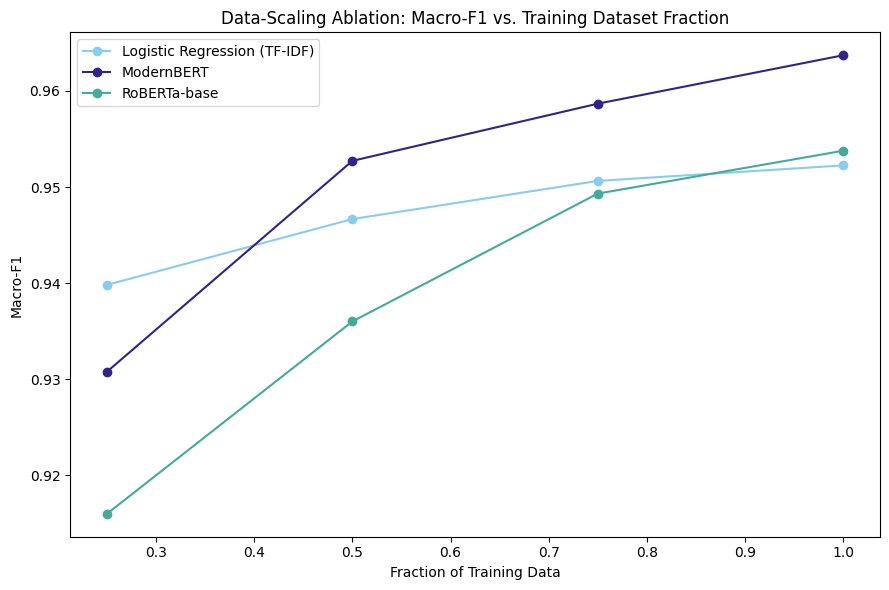

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = {"Logistic Regression (TF-IDF)": "#88CCEE", "RoBERTa-base": "#44AA99", "ModernBERT": "#332288"}

for model_name, group in combined_df.groupby("model"):
    group = group.sort_values("train_fraction")
    ax.plot(group["train_fraction"], group["macro_f1"],
            marker="o", label=model_name, color=colors.get(model_name))

ax.set_xlabel("Fraction of Training Data")
ax.set_ylabel("Macro-F1")
ax.set_title("Data-Scaling Ablation: Macro-F1 vs. Training Dataset Fraction")
ax.legend()
plt.tight_layout()

fig.savefig(f'{DRIVE_DIR_2}/all_models_ablation_comparison.png', dpi=150, bbox_inches="tight")
plt.show()